# **Disease Prediction from Medical Data in Python**

- **What is Disease Prediction?**

Disease prediction is one of the most important applications of machine learning in healthcare. It helps predict whether a patient is likely to have a disease based on medical information such as age, blood pressure, glucose level, BMI, insulin level, and other clinical measurements.

# **Tools and Libraries Used**
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

# **Step 1: Load the Dataset**

Download the **Diabetes Dataset** from Kaggle.

**Dataset Link**

https://www.kaggle.com/datasets/mathchi/diabetes-data-set

or

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [3]:
import pandas as pd

df = pd.read_csv("diabetes.csv")



# **Step 2: Understand the Dataset**
**Display first five rows**

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Dataset shape**

In [7]:
df.shape

(768, 9)

**Describe dataset**

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **Step 3: Data Preprocessing**
**Check Missing Values**

In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# **Step 4: Data Visualization**
**Distribution of Age**

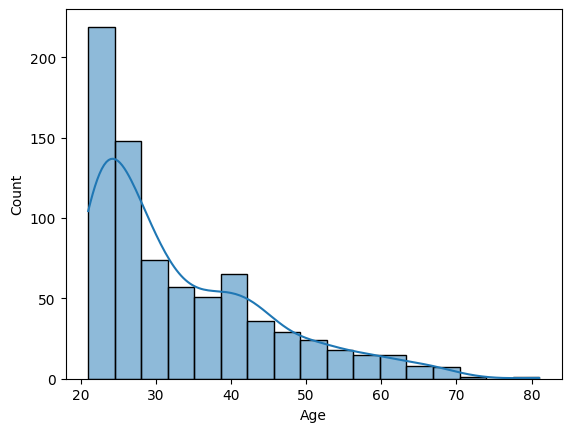

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Age"], kde=True)
plt.show()

**Outcome Count**

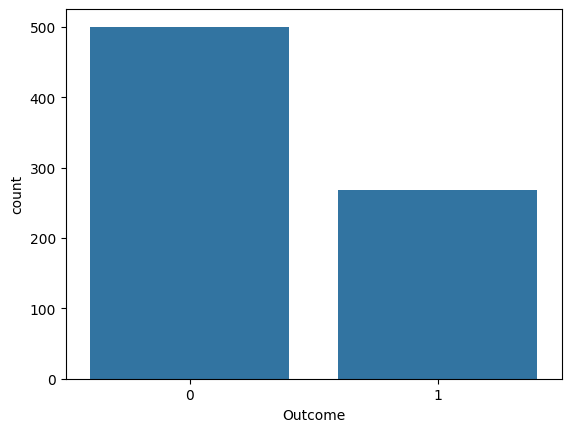

In [11]:
sns.countplot(x="Outcome", data=df)
plt.show()

**Correlation Heatmap**

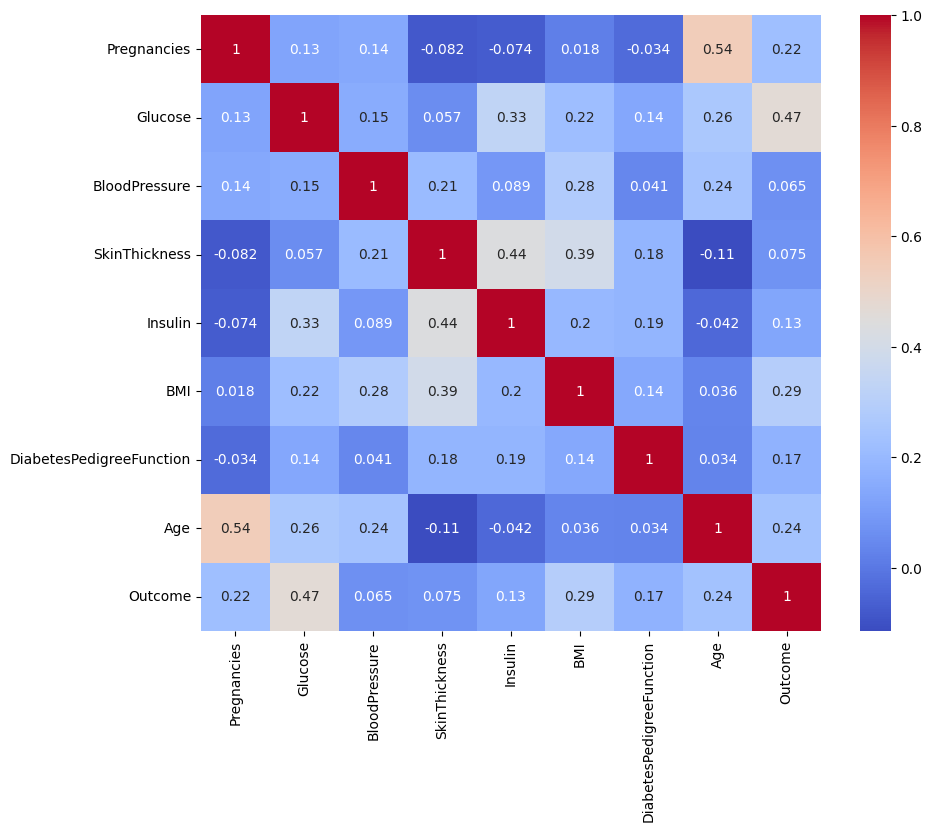

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

# **Step 5: Feature Engineering**
**Features and Target**

In [14]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

**Feature Scaling**

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

# **Step 6: Model Training**
**Train-Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Logistic Regression**

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

**Decision Tree**

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

**Random Forest**

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

# **Model Evaluation**

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for name, pred in models.items():

    print("="*50)

    print("Model:", name)

    print("Accuracy:", accuracy_score(y_test, pred))

    print("\nClassification Report")

    print(classification_report(y_test, pred))

Model: Logistic Regression
Accuracy: 0.7532467532467533

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Model: Decision Tree
Accuracy: 0.7467532467532467

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Model: Random Forest
Accuracy: 0.7337662337662337

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1

# **Recommendation**

✅ Recommendation

• Logistic Regression achieved the highest accuracy (75.32%) among the three models and is selected as the best-performing model for this disease prediction task.

• Decision Tree produced comparable results but with slightly lower accuracy and may be more prone to overfitting.

• Random Forest also performed well, but its accuracy (73.38%) was lower than Logistic Regression on this dataset.

• The current model can assist in predicting the likelihood of diabetes based on patient health parameters. However, it should be used only as a decision-support tool and not as a replacement for professional medical diagnosis.

